In [1]:
import matplotlib.pyplot as plt
from MedtronicPerceptAnalysisTool import PatientDatasetRegistry
from MedtronicPerceptAnalysisTool.plotter.all_patients.all_patients import plot_freqRange_powerMean_of_treatment1_2_normalized_intertreatment_baseline
from MedtronicPerceptAnalysisTool.utility.constants import FrequencyRange
import pandas as pd
import numpy as np
from MedtronicPerceptAnalysisTool.plotter.all_patients.all_patients import plot_all_hemi_type_inter
import numpy as np
from scipy import stats
from scipy.stats import ttest_ind, wilcoxon, ranksums, mannwhitneyu, ttest_rel
from matplotlib import cm as cmap
import dateutil 
import copy
viridis = cmap.get_cmap('gist_ncar', 15)
import warnings
import statsmodels.api as sm
import statsmodels.formula.api as smf
warnings.filterwarnings("ignore", category=DeprecationWarning) 

df_all = PatientDatasetRegistry().all_dataframe_lfp()

freq_range = FrequencyRange.Beta.value
nopeaks = [2,3,5,8,9]

C:\Users\Jesse\AppData\Local\Temp\ipykernel_40068\3772305966.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cmap.get_cmap('gist_ncar', 15)


In [2]:
def round1000(value):
    return np.round(value*100)/100

def round10000p(value):
    return np.round(value*10000)/10000

def gatherPSD(data, p1 = 12, p2 = 30):
    r = data["PSD_(1, 100)"]
    gather = []
    for i,d in enumerate(r):
        w1 = int(np.argwhere(d.frequency==p1))
        w2 = int(np.argwhere(d.frequency==p2))
        gather.append(d.PSD[w1:w2])
    g = np.array(gather)
    return g

def custombox(data,position, scatter = False, sds = False, w = [.5], scattersize = 2, color = 'k',alpha=.5):
    data = np.array(data).flatten()
    plt.boxplot(np.array(data), positions= [position], widths = w)
    if scatter:
        r = np.random.randn(data.shape[0])/30
        plt.scatter(data*0+position+r,data,scattersize,color,alpha=alpha)
    plt.plot([position-w[0]/2, position+w[0]/2],[np.mean(data), np.mean(data)],'g')
    if sds:
        plt.plot([position-w[0]/2, position+w[0]/2],[np.mean(data)-np.std(data)/np.sqrt(data.shape[0]), np.mean(data)-np.std(data)/np.sqrt(data.shape[0])],'g', alpha=.5)
        plt.plot([position-w[0]/2, position+w[0]/2],[np.mean(data)+np.std(data)/np.sqrt(data.shape[0]), np.mean(data)+np.std(data)/np.sqrt(data.shape[0])],'g', alpha=.5)

def customUnravel(data):
    meow = []
    for i in data:
        for j in i:
            meow.append(j)
    return np.array(meow).flatten()

def exportFigure(name):
    plt.savefig(name+".svg")
    plt.savefig(name+".png")

def printTtest(data1,data2,name1,name2):
    a = stats.ttest_ind(data1.flatten(),data2.flatten())
    print(name1," vs. ",name2)
    
    if a.pvalue <= 0.05:
        print("Significant, p: ", a.pvalue)
    else:
        print("Non-significant, p: ", a.pvalue)
    
    print(name1, " mean is: ", round1000(np.mean(data1)), " SEM is: ", round1000(np.std(data1)/np.sqrt(len(data1))), " Median is: ", round1000(np.median(data1)))
    print(name2, " mean is: ", round1000(np.mean(data2)), " SEM is: ", round1000(np.std(data2)/np.sqrt(len(data2))), " Median is: ", round1000(np.median(data2)))
    print("")
    return a.pvalue

def statoutLMEM(model):  
    rvs_change = model.params["Condition[T.C) RVS]"]
    rvs_se = model.bse["Condition[T.C) RVS]"]
    rvs_p = model.pvalues["Condition[T.C) RVS]"]
    ci = model.conf_int(alpha=0.1)
    print("\nDBS-off Mean: "  ,     round1000(model.params["Intercept"]),\
          "\nDBS-off SEM: ",      round1000(model.bse["Intercept"]),\
          "\nDBS-off CI: ",      "[",round1000(ci[0][0]),", ",round1000(ci[1][0]),"]"\
          "\n")
    print("\nAll-on Mean: "  ,     round1000(model.params["Condition[T.B) Allon]"]+model.params["Intercept"]),\
          "\nAll-on SEM: ",      round1000(model.bse["Condition[T.B) Allon]"]),\
          "\nAll-on CI: ",      "[",round1000(ci[0][1]),", ",round1000(ci[1][1]),"]"\
          "\n")
    print("\nRVS Mean: "  ,    round1000(model.params["Condition[T.C) RVS]"]+model.params["Intercept"]),\
          "\nRVS SEM: ",      round1000(model.bse["Condition[T.C) RVS]"]),\
          "\nRVS CI: ",      "[",round1000(ci[0][2]),", ",round1000(ci[1][2]),"]"\
          "\n")
    contrast = "Condition[T.C) RVS] - Condition[T.B) Allon] = 0"
    wald_test = model.wald_test(contrast)
    print("\nDBS-off vs. All-on: ", round10000p( model.pvalues["Condition[T.B) Allon]"]),\
          "\nDBS-off vs. RVS: ", round10000p( model.pvalues["Condition[T.C) RVS]"]),\
          "\nAll-on vs. RVS: ", round10000p(wald_test.pvalue),\
          "\n")  
    return 0

def statout(base,allon,rvs):
    print("DBS-off mean: "  ,     round1000(np.mean(base)),\
          "\nDBS-off median: ",   round1000(np.median(base)),\
          "\nDBS-off st. dev.: ", round1000(np.std(base)),\
          "\nDBS-off SEM: ",      round1000(np.std(base)/np.sqrt(len(base))),\
          "\n")
    print("All-on mean: "  ,     round1000(np.mean(allon)),\
          "\nAll-on median: ",   round1000(np.median(allon)),\
          "\nAll-on st. dev.: ", round1000(np.std(allon)),\
          "\nAll-on SEM: ",      round1000(np.std(allon)/np.sqrt(len(allon))),\
          "\n")
    print("RVS mean: "  ,     round1000(np.mean(rvs)),\
          "\nRVS median: ",   round1000(np.median(rvs)),\
          "\nRVS st. dev.: ", round1000(np.std(rvs)),\
          "\nRVS SEM: ",      round1000(np.std(rvs)/np.sqrt(len(rvs))),\
          "\n")
    return 0

def gen_DataSliceMean(data, p1 = 13, p2 = 30, baseCut = -3, testCut = -6, toMax = False):
    dr = []
    
    base = data.loc[(data["TreatmentBranch"] == "dbs_off")]
    allon = data.loc[(data["TreatmentBranch"] == "all_on")]
    rvs = data.loc[(data["TreatmentBranch"] == "rvs")]
    
    mg = np.ndarray(len(np.unique(base["PatientNumber"]))*2)
    maxmult = np.ndarray(len(np.unique(base["PatientNumber"]))*2)
    xi = 0
    for x,p in enumerate(base.groupby("PatientNumber")):
        for j,c in enumerate(p[1].groupby("IpsiContra")):
            gather = gatherPSD(c[1], p1, p2)
            
            mg[xi] = np.mean(gather[baseCut:])
            #if toMax:
            #    mg[xi] = np.mean(np.max(gather[-baseCut:],axis=1))
            gather = gather/mg[xi]
            if toMax:
                maxmult[xi] = np.mean(np.max(gather[baseCut:,:],axis=0))
                maxmult[xi] = 1
                gather = (gather-maxmult[xi])/maxmult[xi]*100
            else:
                gather = (gather-1)/1*100
            if toMax:
                dr.append({
                "Participant": str(p[1]["PatientNumber"].iloc[0]),
                "Condition": "A) Baseline",
                "Time": np.arange(1,4),
                "Outcome": (np.mean(np.max(gather[baseCut:,:],axis=1)))})
            else:
                dr.append({
                "Participant": str(p[1]["PatientNumber"].iloc[0]),
                "Condition": "A) Baseline",
                "Time": np.arange(1,4),
                "Outcome": (np.mean(np.mean(gather[baseCut:,:],axis=1)))})
            xi += 1
            
    
    xi = 0
    for x,p in enumerate(allon.groupby("PatientNumber")):
        for j,c in enumerate(p[1].groupby("IpsiContra")):
            gather = gatherPSD(c[1], p1, p2)
            gather = gather/mg[xi]
            
            if toMax:
                gather = (gather-maxmult[xi])/maxmult[xi]*100
            else:
                gather = (gather-1)/1*100
                
            if toMax:
                dr.append({
                "Participant": str(p[1]["PatientNumber"].iloc[0]),
                "Condition": "B) Allon",
                "Time": np.arange(1,len(np.max(gather[testCut:,:],axis=1))),
                "Outcome": (np.mean(np.max(gather[testCut:,:],axis=1)))})
            else:
                dr.append({
                "Participant": str(p[1]["PatientNumber"].iloc[0]),
                "Condition": "B) Allon",
                "Time": np.arange(1,len(np.max(gather[testCut:,:],axis=1))),
                "Outcome": (np.mean(np.mean(gather[testCut:,:],axis=1)))})
            xi += 1
    
    xi = 0
    for x,p in enumerate(rvs.groupby("PatientNumber")):
        for j,c in enumerate(p[1].groupby("IpsiContra")):
            gather = gatherPSD(c[1], p1, p2)
            gather = gather/mg[xi]
            
            if toMax:
                gather = (gather-maxmult[xi])/maxmult[xi]*100
            else:
                gather = (gather-1)/1*100
                
            if toMax:
                dr.append({
                "Participant": str(p[1]["PatientNumber"].iloc[0]),
                "Condition": "C) RVS",
                "Time": np.arange(1,len(np.max(gather[testCut:,:],axis=1))),
                "Outcome": (np.mean(np.max(gather[testCut:,:],axis=1)))})
            else:
                dr.append({
                "Participant": str(p[1]["PatientNumber"].iloc[0]),
                "Condition": "C) RVS",
                "Time": np.arange(1,len(np.max(gather[testCut:,:],axis=1))),
                "Outcome": (np.mean(np.mean(gather[testCut:,:],axis=1)))})
            xi += 1   
            
    dataReturn = pd.DataFrame(dr)
    dataReturn = dataReturn.explode("Outcome")
    dataReturn["Outcome"] = pd.to_numeric(dataReturn["Outcome"], errors="coerce")
    return dataReturn

def gen_allSession_Data(data, p1 = 13, p2 = 30, baseCut = -3, testCut = -6, toMax = False):
    base = data.loc[(data["TreatmentBranch"] == "dbs_off")]
    allon = data.loc[(data["TreatmentBranch"] == "all_on")]
    rvs = data.loc[(data["TreatmentBranch"] == "rvs")]
    
    mg = np.ndarray(len(np.unique(base["PatientNumber"]))*2)
    maxmult = np.ndarray(len(np.unique(base["PatientNumber"]))*2)
    baseValues = []
    baseMeans =  []
    xi = 0
    for x,p in enumerate(base.groupby("PatientNumber")):
        for j,c in enumerate(p[1].groupby("IpsiContra")):
            gather = gatherPSD(c[1], p1, p2)
            
            mg[xi] = np.mean(gather[baseCut:])
            #if toMax:
            #    mg[xi] = np.mean(np.max(gather[-baseCut:],axis=1))
            gather = gather/mg[xi]
            if toMax:
                maxmult[xi] = np.mean(np.max(gather[-baseCut:,:],axis=0))
                maxmult[xi] = 1
                gather = (gather-maxmult[xi])/maxmult[xi]*100
            else:
                gather = (gather-1)/1*100
            if toMax:
                baseValues.append(np.max(gather[baseCut:,:],axis=1))
                baseMeans.append( np.mean(np.max(gather[baseCut:,:],axis=1)) )
            else:
                baseValues.append(np.mean(gather[baseCut:,:],axis=1))
                baseMeans.append( np.mean(np.mean(gather[baseCut:,:],axis=1)) )
            xi += 1
    baseValues = customUnravel(baseValues)
    baseMeans =  np.array(baseMeans).flatten()
    
    allValues = []
    allMeans = []
    xi = 0
    for x,p in enumerate(allon.groupby("PatientNumber")):
        for j,c in enumerate(p[1].groupby("IpsiContra")):
            gather = gatherPSD(c[1], p1, p2)
            gather = gather/mg[xi]
            
            if toMax:
                gather = (gather-maxmult[xi])/maxmult[xi]*100
            else:
                gather = (gather-1)/1*100
                
            if toMax:
                allValues.append(np.max(gather[testCut:,:],axis=1))
                allMeans.append( np.mean(np.max(gather[testCut:,:],axis=1)) )
            else:
                allValues.append(np.mean(gather[testCut:,:],axis=1))
                allMeans.append( np.mean(np.mean(gather[testCut:,:],axis=1)) )
            
            xi += 1
    allValues = customUnravel(allValues)
    allMeans =  np.array(allMeans).flatten()
    
    rvsValues = []
    rvsMeans = []
    xi = 0
    for x,p in enumerate(rvs.groupby("PatientNumber")):
        for j,c in enumerate(p[1].groupby("IpsiContra")):
            gather = gatherPSD(c[1], p1, p2)
            gather = gather/mg[xi]
            
            if toMax:
                gather = (gather-maxmult[xi])/maxmult[xi]*100
            else:
                gather = (gather-1)/1*100
                
            if toMax:
                rvsValues.append(np.max(gather[testCut:,:],axis=1))
                rvsMeans.append( np.mean(np.max(gather[testCut:,:],axis=1)) )
            else:
                rvsValues.append(np.mean(gather[testCut:,:],axis=1))
                rvsMeans.append( np.mean(np.mean(gather[testCut:,:],axis=1)) )
            xi += 1
    rvsValues = customUnravel(rvsValues)
    rvsMeans =  np.array(rvsMeans).flatten()
    
    return baseValues, baseMeans, allValues, allMeans, rvsValues, rvsMeans

def gen_allSession_Data_maxInd(data, p1 = 13, p2 = 30, baseCut = -3, testCut = -6, toMax = False):
    base = data.loc[(data["TreatmentBranch"] == "dbs_off")]
    allon = data.loc[(data["TreatmentBranch"] == "all_on")]
    rvs = data.loc[(data["TreatmentBranch"] == "rvs")]
    
    mg = np.ndarray(len(np.unique(base["PatientNumber"]))*2)
    maxind = np.ndarray(len(np.unique(base["PatientNumber"]))*2,dtype="int16")
    
    baseValues = []
    baseMeans =  []
    xi = 0
    for x,p in enumerate(base.groupby("PatientNumber")):
        for j,c in enumerate(p[1].groupby("IpsiContra")):
            gather = gatherPSD(c[1], p1, p2)
            mg[xi] = np.mean(gather[-baseCut:])
            #maxind[xi] = np.argmax(np.mean(gather,axis=0))
            maxind[xi] = np.argmax(gather[0,:])

            gather = gather/mg[xi]
            gather = (gather-1)/1*100
            baseValues.append(gather[baseCut:,maxind[xi]])
            baseMeans.append( np.mean(gather[baseCut:,maxind[xi]]) )
            xi += 1
    baseValues = customUnravel(baseValues)
    baseMeans =  np.array(baseMeans).flatten()
    
    allValues = []
    allMeans = []
    xi = 0
    for x,p in enumerate(allon.groupby("PatientNumber")):
        for j,c in enumerate(p[1].groupby("IpsiContra")):
            gather = gatherPSD(c[1], p1, p2)
            gather = gather/mg[xi]
            gather = (gather-1)/1*100
            allValues.append(gather[testCut:,maxind[xi]])
            allMeans.append( np.mean(gather[testCut:,maxind[xi]]) )
            
            xi += 1
    allValues = customUnravel(allValues)
    allMeans =  np.array(allMeans).flatten()
    
    rvsValues = []
    rvsMeans = []
    xi = 0
    for x,p in enumerate(rvs.groupby("PatientNumber")):
        for j,c in enumerate(p[1].groupby("IpsiContra")):
            gather = gatherPSD(c[1], p1, p2)
            gather = gather/mg[xi]
            gather = (gather-1)/1*100
            rvsValues.append(gather[testCut:,maxind[xi]])
            rvsMeans.append( np.mean(gather[testCut:,maxind[xi]]) )
            xi += 1
    rvsValues = customUnravel(rvsValues)
    rvsMeans =  np.array(rvsMeans).flatten()
    
    return baseValues, baseMeans, allValues, allMeans, rvsValues, rvsMeans

def gen_peaked_Data(data, p1 = 13, p2 = 30, baseCut = -3, testCut = -6, toMax = False, peaks = True):
    base = data.loc[(data["TreatmentBranch"] == "dbs_off")]
    allon = data.loc[(data["TreatmentBranch"] == "all_on")]
    rvs = data.loc[(data["TreatmentBranch"] == "rvs")]
    
    mg = np.ndarray(len(np.unique(base["PatientNumber"]))*2)
    
    baseValues = []
    baseMeans =  []
    xi = 0
    for x,p in enumerate(base.groupby("PatientNumber")):
        if peaks:
            if p[1]["PatientNumber"].iloc[0] in nopeaks:
                continue
        if not peaks:
            if p[1]["PatientNumber"].iloc[0] not in nopeaks:
                continue
        print(p[1]["PatientNumber"].iloc[0])
        for j,c in enumerate(p[1].groupby("IpsiContra")):
            gather = gatherPSD(c[1], p1, p2)
            if peak:
                mg[xi] = np.max(gather[-baseCut:])
            else:
                mg[xi] = np.mean(gather[-baseCut:])
            gather = gather/mg[xi]
            gather = (gather-1)/1*100
            baseValues.append(np.mean(gather[baseCut:,:],axis=1))
            baseMeans.append( np.mean(np.mean(gather[baseCut:,:],axis=1)) )
            xi += 1
    baseValues = customUnravel(baseValues)
    baseMeans =  np.array(baseMeans).flatten()
    
    allValues = []
    allMeans = []
    xi = 0
    for x,p in enumerate(allon.groupby("PatientNumber")):
        if peaks:
            if p[1]["PatientNumber"].iloc[0] in nopeaks:
                continue
        if not peaks:
            if p[1]["PatientNumber"].iloc[0] not in nopeaks:
                continue
        for j,c in enumerate(p[1].groupby("IpsiContra")):
            gather = gatherPSD(c[1], p1, p2)
            gather = gather/mg[xi]
            gather = (gather-1)/1*100
            allValues.append(np.mean(gather[testCut:,:],axis=1))
            allMeans.append( np.mean(np.mean(gather[testCut:,:],axis=1)) )
            xi += 1
    allValues = customUnravel(allValues)
    allMeans =  np.array(allMeans).flatten()
    
    rvsValues = []
    rvsMeans = []
    xi = 0
    for x,p in enumerate(rvs.groupby("PatientNumber")):
        if peaks:
            if p[1]["PatientNumber"].iloc[0] in nopeaks:
                continue
        if not peaks:
            if p[1]["PatientNumber"].iloc[0] not in nopeaks:
                continue
        for j,c in enumerate(p[1].groupby("IpsiContra")):
            gather = gatherPSD(c[1], p1, p2)
            gather = gather/mg[xi]
            gather = (gather-1)/1*100
            rvsValues.append(np.mean(gather[testCut:,:],axis=1))
            rvsMeans.append( np.mean(np.mean(gather[testCut:,:],axis=1)) )
            xi += 1
    rvsValues = customUnravel(rvsValues)
    rvsMeans =  np.array(rvsMeans).flatten()
    
    return baseValues, baseMeans, allValues, allMeans, rvsValues, rvsMeans

def gen_DataSlice(data, p1 = 13, p2 = 30, baseCut = -3, testCut = -6, toMax = False):
    dr = []
    
    base = data.loc[(data["TreatmentBranch"] == "dbs_off")]
    allon = data.loc[(data["TreatmentBranch"] == "all_on")]
    rvs = data.loc[(data["TreatmentBranch"] == "rvs")]
    
    mg = np.ndarray(len(np.unique(base["PatientNumber"]))*2)
    maxmult = np.ndarray(len(np.unique(base["PatientNumber"]))*2)
    xi = 0
    for x,p in enumerate(base.groupby("PatientNumber")):
        for j,c in enumerate(p[1].groupby("IpsiContra")):
            gather = gatherPSD(c[1], p1, p2)
            per = []
            if c[1]["TreatmentOrder"].iloc[0] == "dbs_off,rvs,all_on":
                per = "BLAB"
            else:
                per = "BLBA"
            mg[xi] = np.mean(gather[baseCut:])
            #if toMax:
            #    mg[xi] = np.mean(np.max(gather[-baseCut:],axis=1))
            gather = gather/mg[xi]
            if toMax:
                maxmult[xi] = np.mean(np.max(gather[baseCut:,:],axis=0))
                maxmult[xi] = 1
                gather = (gather-maxmult[xi])/maxmult[xi]*100
            else:
                gather = (gather-1)/1*100
            if toMax:
                dr.append({
                "Participant": str(p[1]["PatientNumber"].iloc[0]),
                "Condition": "A) Baseline",
                "Period": c[1]["TreatmentOrder"].iloc[0],
                "Outcome": tuple(np.max(gather[baseCut:,:],axis=1))})
            else:
                dr.append({
                "Participant": str(p[1]["PatientNumber"].iloc[0]),
                "Condition": "A) Baseline",
                "Period": c[1]["TreatmentOrder"].iloc[0],
                "Outcome": tuple(np.mean(gather[baseCut:,:],axis=1))})
            xi += 1
            
    
    xi = 0
    for x,p in enumerate(allon.groupby("PatientNumber")):
        for j,c in enumerate(p[1].groupby("IpsiContra")):
            gather = gatherPSD(c[1], p1, p2)
            gather = gather/mg[xi]
            per = []
            if c[1]["TreatmentOrder"].iloc[0] == "dbs_off,rvs,all_on":
                per = "AB"
            else:
                per = "BA"
                
            if toMax:
                gather = (gather-maxmult[xi])/maxmult[xi]*100
            else:
                gather = (gather-1)/1*100
                
            if toMax:
                dr.append({
                "Participant": str(p[1]["PatientNumber"].iloc[0]),
                "Condition": "B) Allon",
                "Period": c[1]["TreatmentOrder"].iloc[0],
                "Outcome": tuple(np.max(gather[testCut:,:],axis=1))})
            else:
                dr.append({
                "Participant": str(p[1]["PatientNumber"].iloc[0]),
                "Condition": "B) Allon",
                "Period": c[1]["TreatmentOrder"].iloc[0],
                "Outcome": tuple(np.mean(gather[testCut:,:],axis=1))})
            xi += 1
    
    xi = 0
    for x,p in enumerate(rvs.groupby("PatientNumber")):
        for j,c in enumerate(p[1].groupby("IpsiContra")):
            gather = gatherPSD(c[1], p1, p2)
            gather = gather/mg[xi]
            per = []
            if c[1]["TreatmentOrder"].iloc[0] == "dbs_off,rvs,all_on":
                per = "AB"
            else:
                per = "BA"
                
            
            if toMax:
                gather = (gather-maxmult[xi])/maxmult[xi]*100
            else:
                gather = (gather-1)/1*100
                
            if toMax:
                dr.append({
                "Participant": str(p[1]["PatientNumber"].iloc[0]),
                "Condition": "C) RVS",
                "Period": c[1]["TreatmentOrder"].iloc[0],
                "Outcome": tuple(np.max(gather[testCut:,:],axis=1))})
            else:
                dr.append({
                "Participant": str(p[1]["PatientNumber"].iloc[0]),
                "Condition": "C) RVS",
                "Period": c[1]["TreatmentOrder"].iloc[0],
                "Outcome": tuple(np.mean(gather[testCut:,:],axis=1))})
            xi += 1   
            
    dataReturn = pd.DataFrame(dr)
    dataReturn = dataReturn.explode("Outcome")
    dataReturn["Outcome"] = pd.to_numeric(dataReturn["Outcome"], errors="coerce")
    dataReturn["Period"] = dataReturn["Period"].astype(str)
    return dataReturn

## How to get peaked data:

In [3]:
p1 = 13
p2 = 30

data = copy.deepcopy(df_all)
data = data[(~data["PatientNumber"].isin(nopeaks))]
print(np.unique(data["PatientNumber"]))
print(nopeaks)

[ 1  4  7 10 11 12 13]
[2, 3, 5, 8, 9]


peaked:
1 contra
1 ipsi
7 contra
7 ipsi
10 contra
10 ipsi
12 contra
12 ipsi
13 contra
13 ipsi
4 contra
8 ipsi
11 contra

In [4]:
data2 = copy.deepcopy(df_all)
data2["Peak"] = False
for index in range(data2.shape[0]):
    if data2['PatientNumber'].iloc[index] in [1,7,10,12,13]:
        data2["Peak"].iloc[index] = True
    if data2['PatientNumber'].iloc[index] in [4,11]:
        if data2["IpsiContra"].iloc[index] == "contra":
            data2["Peak"].iloc[index] = True
    if data2['PatientNumber'].iloc[index] == 8:
        if data2["IpsiContra"].iloc[index] == "ipsi":
            data2["Peak"].iloc[index] = True

C:\Users\Jesse\AppData\Local\Temp\ipykernel_40068\1609219108.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data2["Peak"].iloc[index] = True
C:\Users\Jesse\AppData\Local\Temp\ipykernel_40068\1609219108.py:5: SettingWithCopyWarning: 
A v

## Plots from Fig 3 with ratio change and from 10-30

## Now with percent change:

2 contra
3 contra
3 ipsi
5 contra
8 contra
9 contra
9 ipsi


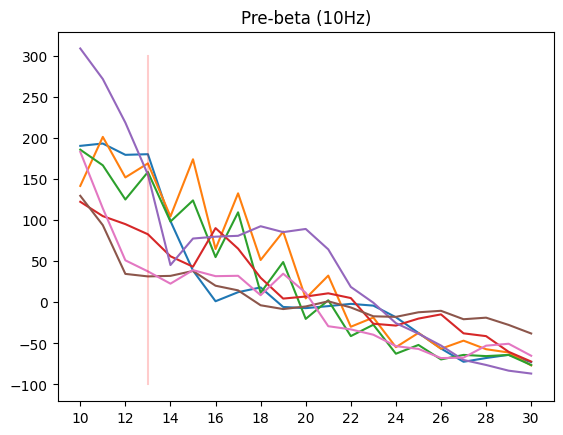

1 contra
1 ipsi
4 contra
7 contra
7 ipsi
8 ipsi
10 contra
10 ipsi
11 contra
12 contra
12 ipsi
13 contra
13 ipsi


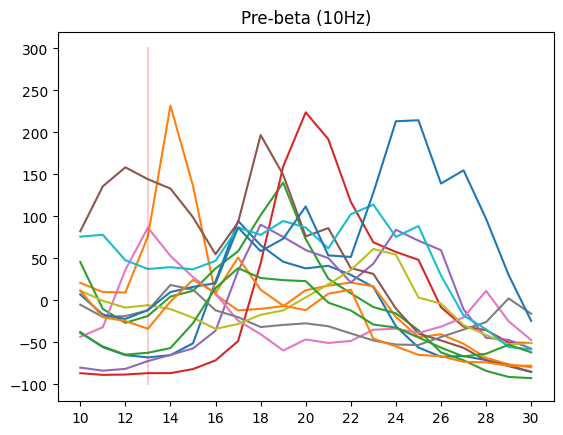

In [5]:
p1 = 13
p2 = 30
mdata = dict()

for x,p in enumerate(df_all.groupby("PatientNumber")):        
    for j,c in enumerate(p[1].groupby("IpsiContra")):
        data = c[1]
        basei = data.loc[(data["TreatmentBranch"] == "dbs_off")]
        gather = gatherPSD(basei, 10, p2+1)
        mg = np.mean(gather[-3:,2:])
        gather = (gather[0,:]-mg)/mg*100
        if np.argmax(gather) < 3:
            plt.plot(np.arange(10, p2+1),gather)
            print(c[1]["PatientNumber"].iloc[0],c[1]["IpsiContra"].iloc[0])
plt.xticks(np.arange(10, p2+1,2))
plt.plot([13,13],[-100,300],'r',alpha=.2)
plt.title("Pre-beta (10Hz)")
exportFigure("Fig3Aii_NoPeak")
plt.show()

for x,p in enumerate(df_all.groupby("PatientNumber")):        
    for j,c in enumerate(p[1].groupby("IpsiContra")):
        data = c[1]
        basei = data.loc[(data["TreatmentBranch"] == "dbs_off")]
        gather = gatherPSD(basei, 10, p2+1)
        mg = np.mean(gather[-3:,2:])
        gather = (gather[0,:]-mg)/mg*100
        if np.argmax(gather) >= 3:
            plt.plot(np.arange(10, p2+1),gather)
            print(c[1]["PatientNumber"].iloc[0],c[1]["IpsiContra"].iloc[0])
plt.xticks(np.arange(10, p2+1,2))
plt.plot([13,13],[-100,300],'r',alpha=.2)
plt.title("Pre-beta (10Hz)")
exportFigure("Fig3Ai_Peak")
plt.show()


In [6]:
data2 = copy.deepcopy(df_all)
data2["Peak"] = False
for index in range(data2.shape[0]):
    if data2['PatientNumber'].iloc[index] in [1,7,10,12,13]:
        data2["Peak"].iloc[index] = True
    if data2['PatientNumber'].iloc[index] in [4,11]:
        if data2["IpsiContra"].iloc[index] == "contra":
            data2["Peak"].iloc[index] = True
    if data2['PatientNumber'].iloc[index] == 8:
        if data2["IpsiContra"].iloc[index] == "ipsi":
            data2["Peak"].iloc[index] = True

C:\Users\Jesse\AppData\Local\Temp\ipykernel_40068\1609219108.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data2["Peak"].iloc[index] = True
C:\Users\Jesse\AppData\Local\Temp\ipykernel_40068\1609219108.py:5: SettingWithCopyWarning: 
A v

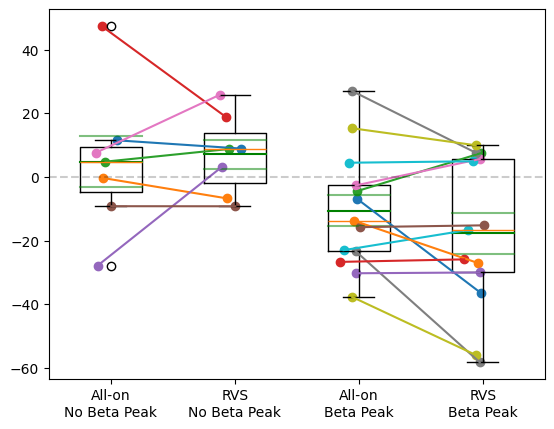

All-on No Beta  vs.  All-on Beta
Non-significant, p:  0.1199687014839999
All-on No Beta  mean is:  4.82  SEM is:  8.01  Median is:  4.79
All-on Beta  mean is:  -10.6  SEM is:  4.96  Median is:  -13.7

RVS No Beta  vs.  RVS Beta
Significant, p:  0.02090868218051275
RVS No Beta  mean is:  7.05  SEM is:  4.44  Median is:  8.77
RVS Beta  mean is:  -17.7  SEM is:  6.37  Median is:  -16.7

All-on No Beta  vs.  RVS No Beta
Non-significant, p:  0.8251549729721659
All-on No Beta  mean is:  4.82  SEM is:  8.01  Median is:  4.79
RVS No Beta  mean is:  7.05  SEM is:  4.44  Median is:  8.77

All-on Beta  vs.  RVS Beta
Non-significant, p:  0.4069889323415534
All-on Beta  mean is:  -10.6  SEM is:  4.96  Median is:  -13.7
RVS Beta  mean is:  -17.7  SEM is:  6.37  Median is:  -16.7

No Beta:
DBS-off mean:  0.0 
DBS-off median:  0.0 
DBS-off st. dev.:  0.0 
DBS-off SEM:  0.0 

All-on mean:  4.82 
All-on median:  4.79 
All-on st. dev.:  21.2 
All-on SEM:  8.01 

RVS mean:  7.05 
RVS median:  8.77 
RVS st

0

In [7]:
p1 = 13
p2 = 30
data = copy.deepcopy(data2[(data2["Peak"] == False)])

baseValues, baseMeans, allValues, allMeans, rvsValues, rvsMeans = gen_allSession_Data(data, p1 = p1, p2 = p2, baseCut = -3, testCut = -6, toMax= False)

custombox(allMeans,1, scatter = False, sds = True, w = [.5], color = 'b',scattersize = 20)
custombox(rvsMeans,2, scatter = False, sds = True, w = [.5], color = 'r',scattersize = 20)
for i,z in enumerate(allMeans):
    r = np.random.normal(1)/20
    plt.plot([1-r,2-r],[z, rvsMeans[i]])
    plt.scatter([1-r,2-r],[z, rvsMeans[i]])


data = copy.deepcopy(data2[(data2["Peak"] == True)])

baseValues, baseMeans2, allValues, allMeans2, rvsValues, rvsMeans2 = gen_allSession_Data(data, p1 = p1, p2 = p2, baseCut = -3, testCut = -6, toMax= False)

custombox(allMeans2,3, scatter = False, sds = True, w = [.5], color = 'b',scattersize = 20)
custombox(rvsMeans2,4, scatter = False, sds = True, w = [.5], color = 'r',scattersize = 20)

for i,z in enumerate(allMeans2):
    r = np.random.normal(1)/20
    plt.plot([3-r,4-r],[z, rvsMeans2[i]])
    plt.scatter([3-r,4-r],[z, rvsMeans2[i]])
plt.plot([.5,4.5],[0,0],'k--',alpha=.2)
plt.xticks([1,2,3,4],labels = ["All-on\nNo Beta Peak","RVS\nNo Beta Peak","All-on\nBeta Peak","RVS\nBeta Peak"])
exportFigure("Fig3B,_PeakvsNoPeak_Mean")
plt.show()

printTtest(allMeans,allMeans2,"All-on No Beta","All-on Beta")
printTtest(rvsMeans,rvsMeans2,"RVS No Beta","RVS Beta")
printTtest(allMeans,rvsMeans,"All-on No Beta","RVS No Beta")
printTtest(allMeans2,rvsMeans2,"All-on Beta","RVS Beta")

print("No Beta:")
statout(baseMeans,allMeans,rvsMeans)
print("Beta:")
statout(baseMeans2,allMeans2,rvsMeans2)

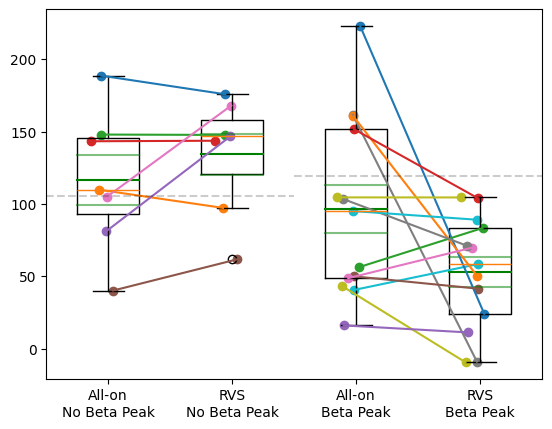

All-on No Beta  vs.  All-on Beta
Non-significant, p:  0.4676814877594129
All-on No Beta  mean is:  116.63  SEM is:  16.98  Median is:  109.85
All-on Beta  mean is:  96.56  SEM is:  16.46  Median is:  95.14

RVS No Beta  vs.  RVS Beta
Significant, p:  0.0003718960733201752
RVS No Beta  mean is:  134.41  SEM is:  14.21  Median is:  146.74
RVS Beta  mean is:  53.08  SEM is:  10.47  Median is:  58.53

All-on No Beta  vs.  RVS No Beta
Non-significant, p:  0.47142939613246926
All-on No Beta  mean is:  116.63  SEM is:  16.98  Median is:  109.85
RVS No Beta  mean is:  134.41  SEM is:  14.21  Median is:  146.74

All-on Beta  vs.  RVS Beta
Significant, p:  0.04261078676180072
All-on Beta  mean is:  96.56  SEM is:  16.46  Median is:  95.14
RVS Beta  mean is:  53.08  SEM is:  10.47  Median is:  58.53

No Beta:
DBS-off mean:  105.43 
DBS-off median:  103.46 
DBS-off st. dev.:  38.97 
DBS-off SEM:  14.73 

All-on mean:  116.63 
All-on median:  109.85 
All-on st. dev.:  44.92 
All-on SEM:  16.98 

RV

0

In [8]:
p1 = 13
p2 = 30
data = copy.deepcopy(data2[(data2["Peak"] == False)])

baseValues, baseMeans, allValues, allMeans, rvsValues, rvsMeans = gen_allSession_Data(data, p1 = p1, p2 = p2, baseCut = -3, testCut = -6, toMax= True)

custombox(allMeans,1, scatter = False, sds = True, w = [.5], color = 'b',scattersize = 20)
custombox(rvsMeans,2, scatter = False, sds = True, w = [.5], color = 'r',scattersize = 20)
for i,z in enumerate(allMeans):
    r = np.random.normal(1)/20
    plt.plot([1-r,2-r],[z, rvsMeans[i]])
    plt.scatter([1-r,2-r],[z, rvsMeans[i]])


data = copy.deepcopy(data2[(data2["Peak"] == True)])

baseValues, baseMeans2, allValues, allMeans2, rvsValues, rvsMeans2 = gen_allSession_Data(data, p1 = p1, p2 = p2, baseCut = -3, testCut = -6, toMax= True)

custombox(allMeans2,3, scatter = False, sds = True, w = [.5], color = 'b',scattersize = 20)
custombox(rvsMeans2,4, scatter = False, sds = True, w = [.5], color = 'r',scattersize = 20)

for i,z in enumerate(allMeans2):
    r = np.random.normal(1)/20
    plt.plot([3-r,4-r],[z, rvsMeans2[i]])
    plt.scatter([3-r,4-r],[z, rvsMeans2[i]])
n = np.mean(baseMeans)
plt.plot([.5,2.5],[n,n],'k--',alpha=.2)
n = np.mean(baseMeans2)
plt.plot([2.5,4.5],[n,n],'k--',alpha=.2)
plt.xticks([1,2,3,4],labels = ["All-on\nNo Beta Peak","RVS\nNo Beta Peak","All-on\nBeta Peak","RVS\nBeta Peak"])
exportFigure("Fig3E_Max_PeakvNOPeak")
plt.show()

printTtest(allMeans,allMeans2,"All-on No Beta","All-on Beta")
printTtest(rvsMeans,rvsMeans2,"RVS No Beta","RVS Beta")
printTtest(allMeans,rvsMeans,"All-on No Beta","RVS No Beta")
printTtest(allMeans2,rvsMeans2,"All-on Beta","RVS Beta")

print("No Beta:")
statout(baseMeans,allMeans,rvsMeans)
print("Beta:")
statout(baseMeans2,allMeans2,rvsMeans2)

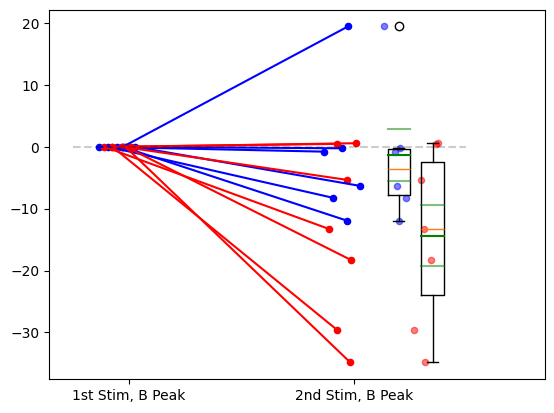

Change as All-on  vs.  Change as RVS
Non-significant, p:  0.09618610101076733
Change as All-on  mean is:  -1.35  SEM is:  4.14  Median is:  -3.55
Change as RVS  mean is:  -14.34  SEM is:  4.93  Median is:  -13.3

DBS-off mean:  0.0 
DBS-off median:  0.0 
DBS-off st. dev.:  0.0 
DBS-off SEM:  0.0 

All-on mean:  -1.35 
All-on median:  -3.55 
All-on st. dev.:  10.15 
All-on SEM:  4.14 

RVS mean:  -14.34 
RVS median:  -13.3 
RVS st. dev.:  13.05 
RVS SEM:  4.93 



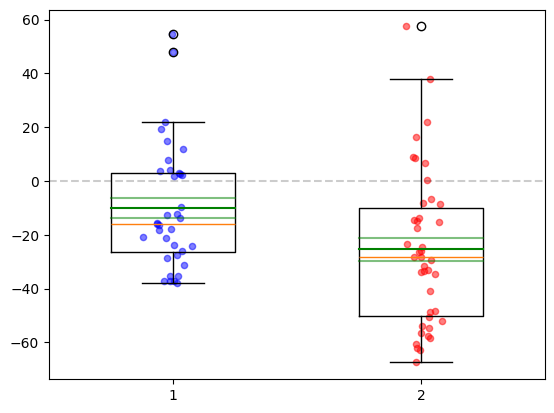

          Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: Effect   
No. Observations:   78      Method:             REML     
No. Groups:         2       Scale:              516.9083 
Min. group size:    10      Log-Likelihood:     -350.5496
Max. group size:    68      Converged:          Yes      
Mean group size:    39.0                                 
---------------------------------------------------------
             Coef.  Std.Err.   z    P>|z|  [0.05   0.95] 
---------------------------------------------------------
Intercept     7.149   20.363  0.351 0.726 -26.346  40.643
Type[T.RVS] -20.638    5.276 -3.912 0.000 -29.316 -11.960
Group Var   775.228   50.475                             



In [15]:
p1 = 13
p2 = 30

data = data2[(data2["Peak"] == True) & (data2["TreatmentOrder"] == "dbs_off,rvs,all_on")]
x, x, allValues, allMeans, rvsValues, rvsMeans = gen_allSession_Data(data, p1 = p1, p2 = p2, baseCut = -3, testCut = -6, toMax= False)
m1 = allMeans-rvsMeans
custombox(allMeans-rvsMeans,2.2, scatter = True, sds = True, w = [.1], color = 'b',scattersize = 20)
for i,z in enumerate(allMeans):
    r = np.random.normal(1)/20
    plt.plot([1-r,2-r],[rvsMeans[i]-rvsMeans[i],z-rvsMeans[i]],'b')
    plt.scatter([1-r,2-r],[rvsMeans[i]-rvsMeans[i],z-rvsMeans[i]],20,'b')

data = data2[(data2["Peak"] == True) & (data2["TreatmentOrder"] == "dbs_off,all_on,rvs")]
x, x, allValues, allMeans, rvsValues, rvsMeans = gen_allSession_Data(data, p1 = p1, p2 = p2, baseCut = -3, testCut = -6, toMax= False)
m2 = rvsMeans-allMeans
custombox(rvsMeans-allMeans,2.35, scatter = True, sds = True, w = [.1], color = 'r',scattersize = 20)
for i,z in enumerate(allMeans):
    r = np.random.normal(1)/20
    plt.plot([1-r,2-r],[allMeans[i]-allMeans[i],rvsMeans[i]-z],'r')
    plt.scatter([1-r,2-r],[allMeans[i]-allMeans[i],rvsMeans[i]-z],20,'r')
plt.plot([.75,2.5],[0,0],'k--',alpha=.2)
plt.xticks([1,2],labels= ["1st Stim, B Peak","2nd Stim, B Peak"])
exportFigure("Fig3C_ChangeIn2ndMean")
plt.show()
printTtest(m1,m2,"Change as All-on","Change as RVS")
statout([0,0,0],m1,m2)

data = data2[(data2["Peak"] == True) & (data2["TreatmentOrder"] == "dbs_off,rvs,all_on")]
x, x, allValues, allMeans, x,x = gen_allSession_Data(data, p1 = p1, p2 = p2, baseCut = -3, testCut = -6, toMax= False)

data = data2[(data2["Peak"] == True) & (data2["TreatmentOrder"] == "dbs_off,all_on,rvs")]
x, x, x, x, rvsValues, rvsMeans = gen_allSession_Data(data, p1 = p1, p2 = p2, baseCut = -3, testCut = -6, toMax= False)
plt.plot([.5,2.5],[0,0],'k--',alpha=.2)
custombox(allValues,1, scatter = True, sds = True, w = [.5], color = 'b',scattersize = 20)
custombox(rvsValues,2, scatter = True, sds = True, w = [.5], color = 'r',scattersize = 20)
exportFigure("Fig3D_ChangeIn2ndMeanDist")
plt.show()

id = []
for x,p in enumerate(df_all.groupby("PatientNumber")):
     for j,c in enumerate(p[1].groupby("IpsiContra")):
         gather = gatherPSD(c[1], 13, 30)
         m = np.max(gather[-6:,:],axis=0)
         id.append(m*0+p[1]["PatientNumber"].iloc[0])
id = np.array(id).flatten()

df = pd.DataFrame(columns=["Type","Effect","Id"])
ip = 0
for x,i in enumerate(allValues):
    df.loc[len(df)] = ["All-on", i, id[x]] 
for x,i in enumerate(rvsValues):
    df.loc[len(df)] = ["RVS", i, id[x]] 
    
model = smf.mixedlm( "Effect ~ Type", data=df, groups=df["Id"]).fit()
print(model.summary(alpha=0.10))


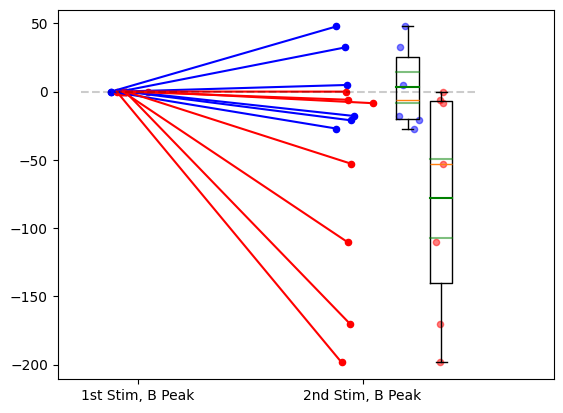

Change as All-on  vs.  Change as RVS
Significant, p:  0.04449909969158425
Change as All-on  mean is:  3.14  SEM is:  11.52  Median is:  -6.52
Change as RVS  mean is:  -78.07  SEM is:  28.86  Median is:  -52.81

DBS-off mean:  0.0 
DBS-off median:  0.0 
DBS-off st. dev.:  0.0 
DBS-off SEM:  0.0 

All-on mean:  3.14 
All-on median:  -6.52 
All-on st. dev.:  28.22 
All-on SEM:  11.52 

RVS mean:  -78.07 
RVS median:  -52.81 
RVS st. dev.:  76.34 
RVS SEM:  28.86 



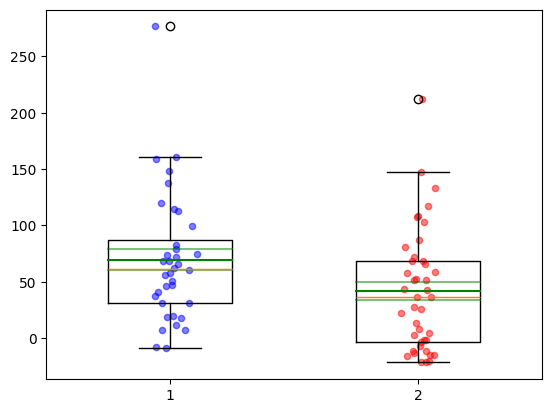

          Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  Effect   
No. Observations:  78       Method:              REML     
No. Groups:        2        Scale:               2756.9036
Min. group size:   10       Log-Likelihood:      -413.6633
Max. group size:   68       Converged:           Yes      
Mean group size:   39.0                                   
----------------------------------------------------------
             Coef.   Std.Err.   z    P>|z|  [0.05   0.95] 
----------------------------------------------------------
Intercept     91.981   29.323  3.137 0.002  43.749 140.213
Type[T.RVS]  -34.697   12.201 -2.844 0.004 -54.766 -14.629
Group Var   1422.443   43.034                             



In [14]:
p1 = 13
p2 = 30

data = data2[(data2["Peak"] == True) & (data2["TreatmentOrder"] == "dbs_off,rvs,all_on")]
x, x, allValues, allMeans, rvsValues, rvsMeans = gen_allSession_Data(data, p1 = p1, p2 = p2, baseCut = -3, testCut = -6, toMax= True)
m1 = allMeans-rvsMeans
custombox(allMeans-rvsMeans,2.2, scatter = True, sds = True, w = [.1], color = 'b',scattersize = 20)
for i,z in enumerate(allMeans):
    r = np.random.normal(1)/20
    plt.plot([1-r,2-r],[rvsMeans[i]-rvsMeans[i],z-rvsMeans[i]],'b')
    plt.scatter([1-r,2-r],[rvsMeans[i]-rvsMeans[i],z-rvsMeans[i]],20,'b')

data = data2[(data2["Peak"] == True) & (data2["TreatmentOrder"] == "dbs_off,all_on,rvs")]
x, x, allValues, allMeans, rvsValues, rvsMeans = gen_allSession_Data(data, p1 = p1, p2 = p2, baseCut = -3, testCut = -6, toMax= True)
m2 = rvsMeans-allMeans
custombox(rvsMeans-allMeans,2.35, scatter = True, sds = True, w = [.1], color = 'r',scattersize = 20)
for i,z in enumerate(allMeans):
    r = np.random.normal(1)/20
    plt.plot([1-r,2-r],[allMeans[i]-allMeans[i],rvsMeans[i]-z],'r')
    plt.scatter([1-r,2-r],[allMeans[i]-allMeans[i],rvsMeans[i]-z],20,'r')
plt.plot([.75,2.5],[0,0],'k--',alpha=.2)
plt.xticks([1,2],labels= ["1st Stim, B Peak","2nd Stim, B Peak"])
exportFigure("Fig3F_ChangeIn2ndMaxDist")
plt.show()
printTtest(m1,m2,"Change as All-on","Change as RVS")

statout([0,0,0],m1,m2)

data = data2[(data2["Peak"] == True) & (data2["TreatmentOrder"] == "dbs_off,rvs,all_on")]
x, x, allValues, allMeans, x,x = gen_allSession_Data(data, p1 = p1, p2 = p2, baseCut = -3, testCut = -6, toMax= True)

data = data2[(data2["Peak"] == True) & (data2["TreatmentOrder"] == "dbs_off,all_on,rvs")]
x, x, x, x, rvsValues, rvsMeans = gen_allSession_Data(data, p1 = p1, p2 = p2, baseCut = -3, testCut = -6, toMax= True)

custombox(allValues,1, scatter = True, sds = True, w = [.5], color = 'b',scattersize = 20)
custombox(rvsValues,2, scatter = True, sds = True, w = [.5], color = 'r',scattersize = 20)
exportFigure("Fig3G_ChangeIn2ndMaxDist")
plt.show()

id = []
for x,p in enumerate(df_all.groupby("PatientNumber")):
     for j,c in enumerate(p[1].groupby("IpsiContra")):
         gather = gatherPSD(c[1], 13, 30)
         m = np.max(gather[-6:,:],axis=0)
         id.append(m*0+p[1]["PatientNumber"].iloc[0])
id = np.array(id).flatten()

df = pd.DataFrame(columns=["Type","Effect","Id"])
ip = 0
for x,i in enumerate(allValues):
    df.loc[len(df)] = ["All-on", i, id[x]] 
for x,i in enumerate(rvsValues):
    df.loc[len(df)] = ["RVS", i, id[x]] 
    
model = smf.mixedlm( "Effect ~ Type", data=df, groups=df["Id"]).fit()
print(model.summary(alpha=0.10))



NameError: name 'linregress' is not defined

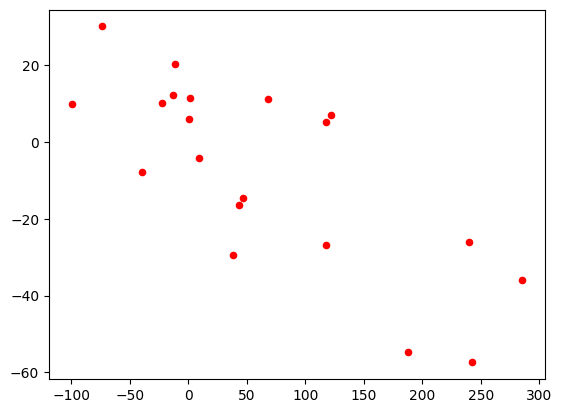

In [11]:
maxgat = []
change = []
for x,p in enumerate(df_all.groupby("PatientNumber")):        
    for j,c in enumerate(p[1].groupby("IpsiContra")):
        data = c[1]
        basei = data.loc[(data["TreatmentBranch"] == "dbs_off")]
        gather = gatherPSD(basei, 10, p2)
        mg = np.mean(gather[-3:,2:])
        gather = (gather-mg)/mg*100
        gua = np.mean(gather,axis=0)
        gm = np.max(gua[0:2])
        gb = np.max(gua[2:])
        maxgat.append(gb-gm)
        basei = data.loc[(data["TreatmentBranch"] == "rvs")]
        gather = gatherPSD(basei, 10, p2)
        gather = (gather-mg)/mg*100
        change.append(np.mean(gather[-6:,2:]))
plt.scatter(maxgat,change,20,'r')
b = linregress(maxgat,change)
print(b)
plt.plot(np.sort(np.array(maxgat)), b.intercept + b.slope*np.sort(np.array(maxgat)), 'r--', label='fitted line')


maxgat = []
change = []
for x,p in enumerate(df_all.groupby("PatientNumber")):        
    for j,c in enumerate(p[1].groupby("IpsiContra")):
        data = c[1]
        basei = data.loc[(data["TreatmentBranch"] == "dbs_off")]
        gather = gatherPSD(basei, 10, p2)
        mg = np.mean(gather[-3:,2:])
        gather = (gather-mg)/mg*100
        gua = np.mean(gather,axis=0)
        gm = np.max(gua[0:2])
        gb = np.max(gua[2:])
        maxgat.append(gb-gm)
        basei = data.loc[(data["TreatmentBranch"] == "all_on")]
        gather = gatherPSD(basei, 10, p2)
        gather = (gather-mg)/mg*100
        change.append(np.mean(gather[-6:,2:]))


a = linregress(maxgat,change)
print(a)
plt.scatter(maxgat,change,20,'b')
plt.plot(np.sort(np.array(maxgat)), a.intercept + a.slope*np.sort(np.array(maxgat)), 'b--', label='fitted line')
exportFigure("Fig3H_MeansRegression")
plt.show()

print("All-on Regression: ")
print("p-value: ", a.pvalue)
print("r: ", a.rvalue)
print("r^2: ", np.square(a.rvalue))
print("-------")
print("RVS Regression: ")
print("p-value: ", b.pvalue)
print("r: ", b.rvalue)
print("r^2: ", np.square(b.rvalue))
print("-------")

In [ ]:
maxgat = []
change = []
for x,p in enumerate(df_all.groupby("PatientNumber")):        
    for j,c in enumerate(p[1].groupby("IpsiContra")):
        data = c[1]
        if data["IpsiContra"].iloc[0] == "contra":
            basei = data.loc[(data["TreatmentBranch"] == "dbs_off")]
            gather = gatherPSD(basei, 10, p2)
            mg = np.mean(gather[-3:,2:])
            gather = (gather-mg)/mg*100
            gua = np.mean(gather,axis=0)
            gm = np.max(gua[0:2])
            gb = np.max(gua[2:])
            maxgat.append(gb-gm)
            basei = data.loc[(data["TreatmentBranch"] == "rvs")]
            gather = gatherPSD(basei, 10, p2)
            gather = (gather-mg)/mg*100
            change.append(np.mean(gather[-6:,2:]))
plt.scatter(maxgat,change,20,'r')
b = linregress(maxgat,change)
print(b)
plt.plot(np.sort(np.array(maxgat)), b.intercept + b.slope*np.sort(np.array(maxgat)), 'r--', label='fitted line')


maxgat = []
change = []
for x,p in enumerate(df_all.groupby("PatientNumber")):        
    for j,c in enumerate(p[1].groupby("IpsiContra")):
        data = c[1]
        if data["IpsiContra"].iloc[0] == "contra":
            basei = data.loc[(data["TreatmentBranch"] == "dbs_off")]
            gather = gatherPSD(basei, 10, p2)
            mg = np.mean(gather[-3:,2:])
            gather = (gather-mg)/mg*100
            gua = np.mean(gather,axis=0)
            gm = np.max(gua[0:2])
            gb = np.max(gua[2:])
            maxgat.append(gb-gm)
            basei = data.loc[(data["TreatmentBranch"] == "all_on")]
            gather = gatherPSD(basei, 10, p2)
            gather = (gather-mg)/mg*100
            change.append(np.mean(gather[-6:,2:]))


a = linregress(maxgat,change)
print(a)
plt.scatter(maxgat,change,20,'b')
plt.plot(np.sort(np.array(maxgat)), a.intercept + a.slope*np.sort(np.array(maxgat)), 'b--', label='fitted line')
exportFigure("FigS3_MeansRegression_contra")
plt.show()

print("All-on Regression: ")
print("p-value: ", a.pvalue)
print("r: ", a.rvalue)
print("r^2: ", np.square(a.rvalue))
print("-------")
print("RVS Regression: ")
print("p-value: ", b.pvalue)
print("r: ", b.rvalue)
print("r^2: ", np.square(b.rvalue))
print("-------")

In [ ]:
maxgat = []
change = []
for x,p in enumerate(df_all.groupby("PatientNumber")):        
    for j,c in enumerate(p[1].groupby("IpsiContra")):
        data = c[1]
        if data["IpsiContra"].iloc[0] == "ipsi":
            basei = data.loc[(data["TreatmentBranch"] == "dbs_off")]
            gather = gatherPSD(basei, 10, p2)
            mg = np.mean(gather[-3:,2:])
            gather = (gather-mg)/mg*100
            gua = np.mean(gather,axis=0)
            gm = np.max(gua[0:2])
            gb = np.max(gua[2:])
            maxgat.append(gb-gm)
            basei = data.loc[(data["TreatmentBranch"] == "rvs")]
            gather = gatherPSD(basei, 10, p2)
            gather = (gather-mg)/mg*100
            change.append(np.mean(gather[-6:,2:]))
plt.scatter(maxgat,change,20,'r')
b = linregress(maxgat,change)
print(b)
plt.plot(np.sort(np.array(maxgat)), b.intercept + b.slope*np.sort(np.array(maxgat)), 'r--', label='fitted line')


maxgat = []
change = []
for x,p in enumerate(df_all.groupby("PatientNumber")):        
    for j,c in enumerate(p[1].groupby("IpsiContra")):
        data = c[1]
        if data["IpsiContra"].iloc[0] == "ipsi":
            basei = data.loc[(data["TreatmentBranch"] == "dbs_off")]
            gather = gatherPSD(basei, 10, p2)
            mg = np.mean(gather[-3:,2:])
            gather = (gather-mg)/mg*100
            gua = np.mean(gather,axis=0)
            gm = np.max(gua[0:2])
            gb = np.max(gua[2:])
            maxgat.append(gb-gm)
            basei = data.loc[(data["TreatmentBranch"] == "all_on")]
            gather = gatherPSD(basei, 10, p2)
            gather = (gather-mg)/mg*100
            change.append(np.mean(gather[-6:,2:]))


a = linregress(maxgat,change)
print(a)
plt.scatter(maxgat,change,20,'b')
plt.plot(np.sort(np.array(maxgat)), a.intercept + a.slope*np.sort(np.array(maxgat)), 'b--', label='fitted line')
exportFigure("FigS3_MeansRegression_ipsi")
plt.show()

print("All-on Regression: ")
print("p-value: ", a.pvalue)
print("r: ", a.rvalue)
print("r^2: ", np.square(a.rvalue))
print("-------")
print("RVS Regression: ")
print("p-value: ", b.pvalue)
print("r: ", b.rvalue)
print("r^2: ", np.square(b.rvalue))
print("-------")

In [ ]:
maxgat = []
change = []
for x,p in enumerate(df_all.groupby("PatientNumber")):        
    for j,c in enumerate(p[1].groupby("IpsiContra")):
        data = c[1]
        basei = data.loc[(data["TreatmentBranch"] == "dbs_off")]
        gather = gatherPSD(basei, 10, p2)
        mg = np.mean(gather[-3:,2:])
        gather = (gather-mg)/mg*100
        ix = np.argmax(gather[0])
        gua = np.mean(gather,axis=0)
        gm = np.max(gua[0:2])
        gb = np.max(gua[2:])
        maxgat.append(gb-gm)
        basei = data.loc[(data["TreatmentBranch"] == "rvs")]
        gather = gatherPSD(basei, 10, p2)
        gather = (gather-mg)/mg*100
        change.append(np.mean(gather[-6:,ix]))
plt.scatter(maxgat,change,20,'r')
b = linregress(maxgat,change)
print(b)
plt.plot(np.sort(np.array(maxgat)), b.intercept + b.slope*np.sort(np.array(maxgat)), 'r--', label='fitted line')


maxgat = []
change = []
for x,p in enumerate(df_all.groupby("PatientNumber")):        
    for j,c in enumerate(p[1].groupby("IpsiContra")):
        data = c[1]
        basei = data.loc[(data["TreatmentBranch"] == "dbs_off")]
        gather = gatherPSD(basei, 10, p2)
        mg = np.mean(gather[-3:,2:])
        gather = (gather-mg)/mg*100
        ix = np.argmax(gather[0])
        gua = np.mean(gather,axis=0)
        gm = np.max(gua[0:2])
        gb = np.max(gua[2:])
        maxgat.append(gb-gm)
        basei = data.loc[(data["TreatmentBranch"] == "all_on")]
        gather = gatherPSD(basei, 10, p2)
        gather = (gather-mg)/mg*100
        change.append(np.mean(gather[-6:,ix]))


a = linregress(maxgat,change)
print(a)
plt.scatter(maxgat,change,20,'b')
plt.plot(np.sort(np.array(maxgat)), a.intercept + a.slope*np.sort(np.array(maxgat)), 'b--', label='fitted line')
exportFigure("Fig3H_MaxRegression")
plt.show()

print("All-on Regression: ")
print("p-value: ", a.pvalue)
print("r: ", a.rvalue)
print("r^2: ", np.square(a.rvalue))
print("-------")
print("RVS Regression: ")
print("p-value: ", b.pvalue)
print("r: ", b.rvalue)
print("r^2: ", np.square(b.rvalue))
print("-------")

In [ ]:
maxgat = []
change = []
for x,p in enumerate(df_all.groupby("PatientNumber")):        
    for j,c in enumerate(p[1].groupby("IpsiContra")):
        data = c[1]
        if data["IpsiContra"].iloc[0] == "contra":
            basei = data.loc[(data["TreatmentBranch"] == "dbs_off")]
            gather = gatherPSD(basei, 10, p2)
            mg = np.mean(gather[-3:,2:])
            gather = (gather-mg)/mg*100
            ix = np.argmax(gather[0])
            gua = np.mean(gather,axis=0)
            gm = np.max(gua[0:2])
            gb = np.max(gua[2:])
            maxgat.append(gb-gm)
            basei = data.loc[(data["TreatmentBranch"] == "rvs")]
            gather = gatherPSD(basei, 10, p2)
            gather = (gather-mg)/mg*100
            change.append(np.mean(gather[-6:,ix]))
plt.scatter(maxgat,change,20,'r')
b = linregress(maxgat,change)
print(b)
plt.plot(np.sort(np.array(maxgat)), b.intercept + b.slope*np.sort(np.array(maxgat)), 'r--', label='fitted line')


maxgat = []
change = []
for x,p in enumerate(df_all.groupby("PatientNumber")):        
    for j,c in enumerate(p[1].groupby("IpsiContra")):
        data = c[1]
        if data["IpsiContra"].iloc[0] == "contra":
            basei = data.loc[(data["TreatmentBranch"] == "dbs_off")]
            gather = gatherPSD(basei, 10, p2)
            mg = np.mean(gather[-3:,2:])
            gather = (gather-mg)/mg*100
            ix = np.argmax(gather[0])
            gua = np.mean(gather,axis=0)
            gm = np.max(gua[0:2])
            gb = np.max(gua[2:])
            maxgat.append(gb-gm)
            basei = data.loc[(data["TreatmentBranch"] == "all_on")]
            gather = gatherPSD(basei, 10, p2)
            gather = (gather-mg)/mg*100
            change.append(np.mean(gather[-6:,ix]))


a = linregress(maxgat,change)
print(a)
plt.scatter(maxgat,change,20,'b')
plt.plot(np.sort(np.array(maxgat)), a.intercept + a.slope*np.sort(np.array(maxgat)), 'b--', label='fitted line')
exportFigure("FigS3_MaxRegression_contra")
plt.show()

print("All-on Regression: ")
print("p-value: ", a.pvalue)
print("r: ", a.rvalue)
print("r^2: ", np.square(a.rvalue))
print("-------")
print("RVS Regression: ")
print("p-value: ", b.pvalue)
print("r: ", b.rvalue)
print("r^2: ", np.square(b.rvalue))
print("-------")

In [ ]:
maxgat = []
change = []
for x,p in enumerate(df_all.groupby("PatientNumber")):        
    for j,c in enumerate(p[1].groupby("IpsiContra")):
        data = c[1]
        if data["IpsiContra"].iloc[0] == "ipsi":
            basei = data.loc[(data["TreatmentBranch"] == "dbs_off")]
            gather = gatherPSD(basei, 10, p2)
            mg = np.mean(gather[-3:,2:])
            gather = (gather-mg)/mg*100
            ix = np.argmax(gather[0])
            gua = np.mean(gather,axis=0)
            gm = np.max(gua[0:2])
            gb = np.max(gua[2:])
            maxgat.append(gb-gm)
            basei = data.loc[(data["TreatmentBranch"] == "rvs")]
            gather = gatherPSD(basei, 10, p2)
            gather = (gather-mg)/mg*100
            change.append(np.mean(gather[-6:,ix]))
plt.scatter(maxgat,change,20,'r')
b = linregress(maxgat,change)
print(b)
plt.plot(np.sort(np.array(maxgat)), b.intercept + b.slope*np.sort(np.array(maxgat)), 'r--', label='fitted line')


maxgat = []
change = []
for x,p in enumerate(df_all.groupby("PatientNumber")):        
    for j,c in enumerate(p[1].groupby("IpsiContra")):
        data = c[1]
        if data["IpsiContra"].iloc[0] == "ipsi":
            basei = data.loc[(data["TreatmentBranch"] == "dbs_off")]
            gather = gatherPSD(basei, 10, p2)
            mg = np.mean(gather[-3:,2:])
            gather = (gather-mg)/mg*100
            ix = np.argmax(gather[0])
            gua = np.mean(gather,axis=0)
            gm = np.max(gua[0:2])
            gb = np.max(gua[2:])
            maxgat.append(gb-gm)
            basei = data.loc[(data["TreatmentBranch"] == "all_on")]
            gather = gatherPSD(basei, 10, p2)
            gather = (gather-mg)/mg*100
            change.append(np.mean(gather[-6:,ix]))


a = linregress(maxgat,change)
print(a)
plt.scatter(maxgat,change,20,'b')
plt.plot(np.sort(np.array(maxgat)), a.intercept + a.slope*np.sort(np.array(maxgat)), 'b--', label='fitted line')
exportFigure("FigS3_MaxRegression_ipsi")
plt.show()

print("All-on Regression: ")
print("p-value: ", a.pvalue)
print("r: ", a.rvalue)
print("r^2: ", np.square(a.rvalue))
print("-------")
print("RVS Regression: ")
print("p-value: ", b.pvalue)
print("r: ", b.rvalue)
print("r^2: ", np.square(b.rvalue))
print("-------")